In [2]:
import gcinfo
import pandas as pd

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Immigrants to Canada, by country of last permanent residence"')["results"][0])


=== Immigrants to Canada, by country of last permanent residence ===
ID: fc6ad2eb-51f8-467c-be01-c4bda5b6186b
Org: Statistics Canada | Statistique Canada
Notes: <p>This table contains 25 series, with data for years 1955 - 2013 (not all combinations necessarily have data for all years). This table contains data described by the following dimensions (Not all co...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710001001
Citation: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence
DOI:      https://doi.org/10.25318/1710001001-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100010-SDMX.zip


In [3]:
df_origin, df_origin_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip")

Using cached file: cache\17100010-eng.zip


In [4]:
pd.Series(df_origin[["Last permanent residence"]].values.flatten()).unique()

array(['Total immigrants', 'Total Europe', 'Great Britain', 'France',
       'Germany', 'Netherlands', 'Greece', 'Italy', 'Portugal',
       'Other Europe', 'Total Asia', 'Australasia',
       'Total United States, West Indies', 'United States', 'West Indies',
       'All other countries', 'Poland', 'India', 'Hong Kong', 'Vietnam',
       'Philippines', 'Other Asia', 'Africa',
       'Other North and Central America', 'South America'], dtype=object)

In [5]:
df_origin_meta

# These regions should add up to `Total immigrants`
main_regions = [
    "Total Europe",
    "Total Asia",
    "Australasia",
    "Total United States, West Indies",
    "Africa",
    "Other North and Central America",
    "South America",
    "All other countries",
]

In [6]:
df_origin_1955 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "1955"]
df_origin_1955.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [7]:
df_origin_2013 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "2013"]
df_origin_2013.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
4828,2013-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,58246,NaN,NaN,NaN,0
4829,2013-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,7648,NaN,NaN,NaN,0
4830,2013-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,1382,NaN,NaN,NaN,0
4831,2013-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,1779,NaN,NaN,NaN,0
4832,2013-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,251,NaN,NaN,NaN,0


In [8]:
print(df_origin_1955.shape)
df_origin_1955.head()

(64, 15)


,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [9]:
df_origin_1955_main_regions = df_origin_1955[df_origin_1955["Last permanent residence"].isin(main_regions)]
print(df_origin_1955_main_regions.shape)
df_origin_1955_main_regions_summed = (
    df_origin_1955_main_regions
    .assign(YEAR=df_origin_1955_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_1955_main_regions_summed

(20, 15)


,YEAR,Last permanent residence,VALUE
0,1955,All other countries,2625
1,1955,Australasia,1700
2,1955,Total Asia,3662
3,1955,Total Europe,90771
4,1955,"Total United States, West Indies",11188


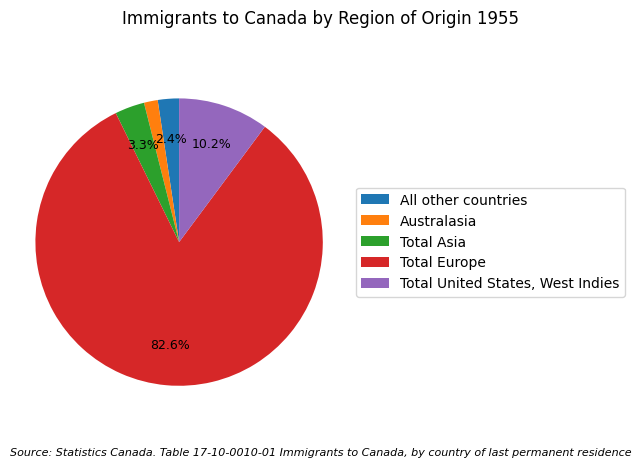

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Last permanent residence": [
        "All other countries",
        "Australasia",
        "Total Asia",
        "Total Europe",
        "Total United States, West Indies"
    ],
    "VALUE": [2625, 1700, 3662, 90771, 11188]
}
df = pd.DataFrame(data)

fig, ax = plt.subplots()

def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 2 else ""

wedges, texts, autotexts = ax.pie(
    df["VALUE"],
    labels=None,
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.72,
    radius=1.1
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

ax.legend(
    wedges,
    df["Last permanent residence"],
    title=None,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True
)

fig.suptitle("Immigrants to Canada by Region of Origin 1955", y=0.95)

plt.figtext(
    0.5, 0.02,
    "Source: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(right=0.68, bottom=0.12, top=0.88)
plt.tight_layout()
plt.show()

In [12]:
df_origin_2013_main_regions = df_origin_2013[df_origin_2013["Last permanent residence"].isin(main_regions)]
print(df_origin_2013_main_regions.shape)
df_origin_2013_main_regions_summed = (
    df_origin_2013_main_regions
    .assign(YEAR=df_origin_2013_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_2013_main_regions_summed

(16, 15)


,YEAR,Last permanent residence,VALUE
0,2013,Africa,17527
1,2013,All other countries,324
2,2013,Australasia,816
3,2013,Other North and Central America,2590
4,2013,South America,4613
5,2013,Total Asia,80438
6,2013,Total Europe,16883
7,2013,"Total United States, West Indies",10495


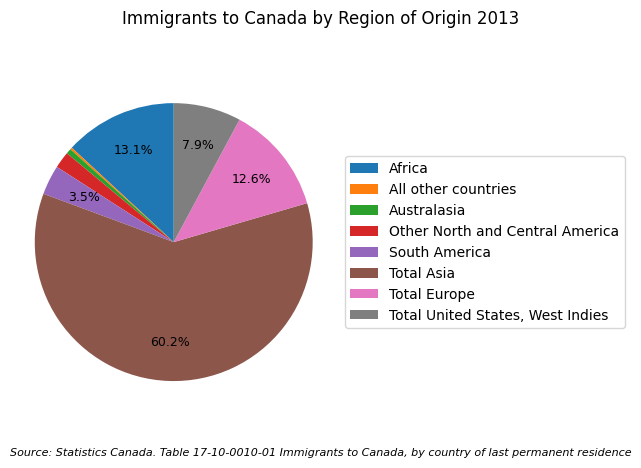

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Last permanent residence": [
        "Africa",
        "All other countries",
        "Australasia",
        "Other North and Central America",
        "South America",
        "Total Asia",
        "Total Europe",
        "Total United States, West Indies"
    ],
    "VALUE": [17527, 324, 816, 2590, 4613, 80438, 16883, 10495]
}
df = pd.DataFrame(data)

fig, ax = plt.subplots()

def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 2 else ""

wedges, texts, autotexts = ax.pie(
    df["VALUE"],
    labels=None,
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.72,
    radius=1.1
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

ax.legend(
    wedges,
    df["Last permanent residence"],
    title=None,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True
)

fig.suptitle("Immigrants to Canada by Region of Origin 2013", y=0.95)

plt.figtext(
    0.5, 0.02,
    "Source: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(right=0.68, bottom=0.12, top=0.88)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
years = [str(y) for y in range(2015, 2024)]
countries = ["United Kingdom", "India", "China", "Philippines", "United States"]

rows = []
for year in years:
    for country in countries:
        rows.append({
            "YEAR": year,
            "Last permanent residence": country,
            "VALUE": np.random.randint(800, 4500)
        })

df_long = pd.DataFrame(rows)
print("Long format (what your groupby gives you):")
print(df_long.head(10))

Long format (what your groupby gives you):
   YEAR Last permanent residence  VALUE
0  2015           United Kingdom   3974
1  2015                    India   4307
2  2015                    China   1660
3  2015              Philippines   2094
4  2015            United States   1930
5  2016           United Kingdom   1895
6  2016                    India   3892
7  2016                    China   2438
8  2016              Philippines   2969
9  2016            United States   1266


In [35]:
df_wide = (
    df_long
    .pivot(index="YEAR", columns="Last permanent residence", values="VALUE")
    .fillna(0)
    .astype(int)
)

print("\nWide format (ready for plotting):")
print(df_wide)


Wide format (ready for plotting):
Last permanent residence  China  India  Philippines  United Kingdom  \
YEAR                                                                  
2015                       1660   4307         2094            3974   
2016                       2438   3892         2969            1895   
2017                       2282   1130         2935            2038   
2018                        930   3719         2485            3971   
2019                       2315   3191         4285            1569   
2020                       1755   2015         3124            3233   
2021                        821   4185         3100            1259   
2022                       1274   4432         1882            3704   
2023                       3547   4347         1775            2847   

Last permanent residence  United States  
YEAR                                     
2015                               1930  
2016                               1266  
2017           

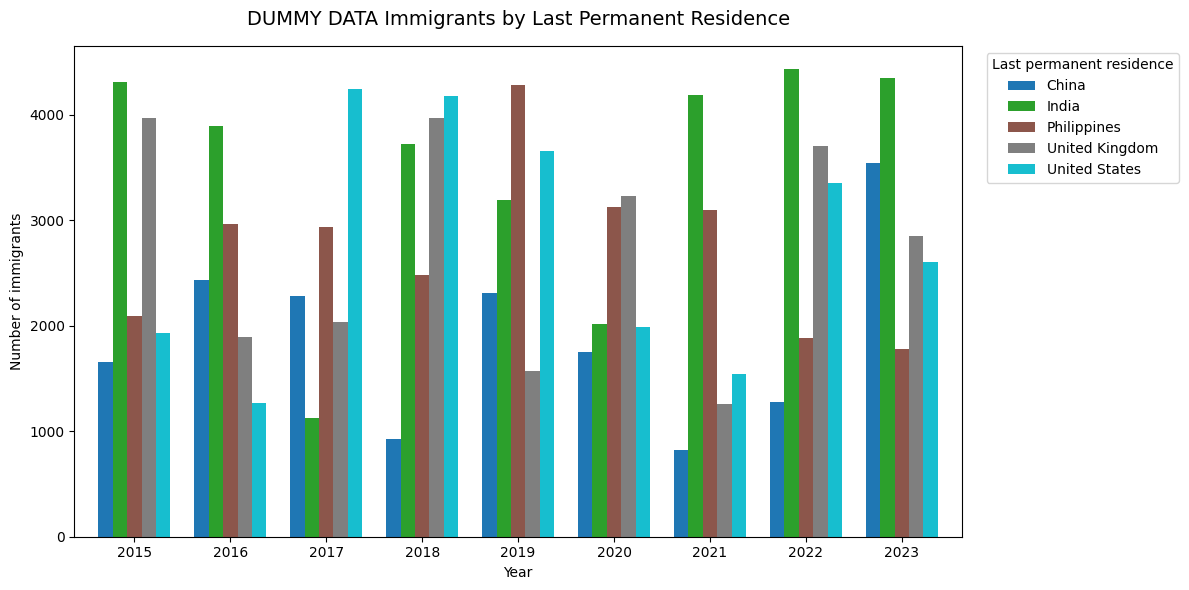

In [40]:
ax = df_wide.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6),
    width=0.75,
    colormap="tab10"          # or "Set2", "tab20", etc.
)

ax.set_title("DUMMY DATA Immigrants by Last Permanent Residence", fontsize=14, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.legend(
    title="Last permanent residence",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
